In [1]:
import numpy as np
import sympy as sp
from full_gddegp.gddegp import gddegp
from scipy.stats import qmc
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
import utils

plt.rcParams.update({'font.size': 12})

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [2]:
n_order = 1
n_bases = 2
num_training_pts = 20
domain_bounds = ((-5.0, 10.0), (0.0, 15.0))
test_grid_resolution = 100
normalize_data = True
kernel = "SE"
kernel_type = "anisotropic"
n_restarts = 15
swarm_size = 200
random_seed = 1
np.random.seed(random_seed)

In [3]:
# Define symbolic Branin function
x_sym, y_sym = sp.symbols('x y')
a, b, c, r, s, t = 1.0, 5.1/(4*sp.pi**2), 5.0/sp.pi, 6.0, 10.0, 1.0/(8*sp.pi)
f_sym = a * (y_sym - b*x_sym**2 + c*x_sym - r)**2 + s*(1 - t)*sp.cos(x_sym) + s

# Compute symbolic gradients
grad_x_sym = sp.diff(f_sym, x_sym)
grad_y_sym = sp.diff(f_sym, y_sym)

# Convert to NumPy functions
true_function_np = sp.lambdify([x_sym, y_sym], f_sym, 'numpy')
grad_x_func = sp.lambdify([x_sym, y_sym], grad_x_sym, 'numpy')
grad_y_func = sp.lambdify([x_sym, y_sym], grad_y_sym, 'numpy')

def true_function(X, alg=np):
    """2D Branin function."""
    return true_function_np(X[:, 0], X[:, 1])

def true_gradient(x, y):
    """Analytical gradient of the Branin function."""
    gx = grad_x_func(x, y)
    gy = grad_y_func(x, y)
    return gx, gy

In [4]:
def clipped_arrow(ax, origin, direction, length, bounds, color="black"):
    """Draw an arrow clipped to plot bounds."""
    x0, y0 = origin
    dx, dy = direction * length
    xlim, ylim = bounds
    tx = np.inf if dx == 0 else (
        xlim[1] - x0)/dx if dx > 0 else (xlim[0] - x0)/dx
    ty = np.inf if dy == 0 else (
        ylim[1] - y0)/dy if dy > 0 else (ylim[0] - y0)/dy
    t = min(1.0, tx, ty)
    ax.arrow(x0, y0, dx*t, dy*t, head_width=0.25,
             head_length=0.35, fc=color, ec=color)

In [5]:
def generate_training_data():
    """Generate GDDEGP training data using pointwise directional derivatives."""
    # 1. Generate points using Latin Hypercube
    sampler = qmc.LatinHypercube(d=n_bases, seed=random_seed)
    unit_samples = sampler.random(n=num_training_pts)
    X_train = qmc.scale(unit_samples,
                        [b[0] for b in domain_bounds],
                        [b[1] for b in domain_bounds])

    # 2. Compute gradient-aligned rays at each training point
    rays_list = []
    for i, (x, y) in enumerate(X_train):
        gx, gy = true_gradient(x, y)
        # Normalize to unit vector
        magnitude = np.sqrt(gx**2 + gy**2)
        ray = np.array([[gx/magnitude], [gy/magnitude]])
        rays_list.append(ray)

    # 3. Compute function values at training points
    y_func = true_function(X_train).reshape(-1, 1)

    # 4. Compute directional derivatives using the chain rule
    # For each point: d_ray = grad_x * ray[0] + grad_y * ray[1]
    directional_derivs = []
    for i, (x, y) in enumerate(X_train):
        gx, gy = true_gradient(x, y)
        ray_direction = rays_list[i].flatten()
        # Directional derivative = gradient · direction
        dir_deriv = gx * ray_direction[0] + gy * ray_direction[1]
        directional_derivs.append(dir_deriv)

    # Stack all directional derivatives into a single array
    directional_derivs_array = np.array(directional_derivs).reshape(-1, 1)

    # 5. Package training data
    # y_train_list should be a list of two arrays, each of shape [num_training_pts, 1]
    y_train_list = [y_func, directional_derivs_array]
    der_indices = [[[1, 1]]]

    return {'X_train': X_train,
            'y_train_list': y_train_list,
            'rays_list': rays_list,
            'der_indices': der_indices}

In [6]:
def train_model(training_data):
    """Initialize and train GDDEGP model."""
    rays_array = np.hstack(training_data['rays_list'])

    gp_model = gddegp(
        training_data['X_train'],
        training_data['y_train_list'],
        n_order=[n_order],
        rays_array=[rays_array],
        der_indices=training_data['der_indices'],
        normalize=normalize_data,
        kernel=kernel,
        kernel_type=kernel_type
    )

    params = gp_model.optimize_hyperparameters(
    optimizer='jade',
    pop_size = 100,
    n_generations = 15,
    local_opt_every = None,
    debug = False
    )
    return gp_model, params

In [7]:
def evaluate_model(gp_model, params, training_data):
    """Evaluate GDDEGP on a test grid."""
    gx = np.linspace(domain_bounds[0][0], domain_bounds[0][1], test_grid_resolution)
    gy = np.linspace(domain_bounds[1][0], domain_bounds[1][1], test_grid_resolution)
    X1_grid, X2_grid = np.meshgrid(gx, gy)
    X_test = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
    N_test = X_test.shape[0]

    # For prediction, we need dummy rays (not used in function value prediction)
    dummy_ray = np.array([[1.0], [0.0]])
    rays_pred = np.hstack([dummy_ray for _ in range(N_test)])

    y_pred_full = gp_model.predict(
        X_test, [rays_pred], params, calc_cov=False, return_deriv=True)
    y_pred = y_pred_full[:N_test]  # Function values only

    y_true = true_function(X_test, alg=np)
    nrmse_val = utils.nrmse(y_true.flatten(), y_pred.flatten())

    return {'X_test': X_test, 'X1_grid': X1_grid, 'X2_grid': X2_grid,
            'y_pred': y_pred, 'y_true': y_true, 'nrmse': nrmse_val,
            'training_data': training_data}

In [8]:
def visualize_results(results):
    """Create 3-panel contour plot: prediction, truth, error."""
    res = results
    training_data = res['training_data']
    X_train, rays_list = training_data['X_train'], training_data['rays_list']
    X1, X2 = res['X1_grid'], res['X2_grid']

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # GDDEGP Prediction
    cf1 = axs[0].contourf(X1, X2, res['y_pred'].reshape(X1.shape),
                           levels=30, cmap='viridis')
    axs[0].scatter(X_train[:, 0], X_train[:, 1], c='red', s=40,
                   edgecolors='k', zorder=5)
    xlim, ylim = (domain_bounds[0], domain_bounds[1])
    for pt, ray in zip(X_train, rays_list):
        clipped_arrow(axs[0], pt, ray.flatten(), length=0.5,
                      bounds=(xlim, ylim), color="black")
    axs[0].set_title("GDDEGP Prediction")
    fig.colorbar(cf1, ax=axs[0])

    # True function
    cf2 = axs[1].contourf(X1, X2, res['y_true'].reshape(X1.shape),
                           levels=30, cmap='viridis')
    axs[1].set_title("True Function")
    fig.colorbar(cf2, ax=axs[1])

    # Absolute Error (log scale)
    abs_error = np.abs(res['y_pred'].flatten() - res['y_true'].flatten()).reshape(X1.shape)
    abs_error_clipped = np.clip(abs_error, 1e-6, None)
    log_levels = np.logspace(np.log10(abs_error_clipped.min()),
                             np.log10(abs_error_clipped.max()), num=100)
    cf3 = axs[2].contourf(X1, X2, abs_error_clipped, levels=log_levels,
                           norm=LogNorm(), cmap="magma_r")
    fig.colorbar(cf3, ax=axs[2])
    axs[2].set_title("Absolute Error (log scale)")

    for ax in axs:
        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_2$")
        ax.set_aspect("equal")

    custom_lines = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
               markeredgecolor='k', markersize=8, label='Train Points'),
        Line2D([0], [0], color='black', lw=2, label='Gradient Ray Direction'),
    ]
    fig.legend(handles=custom_lines, loc='lower center', ncol=2,
               frameon=False, fontsize=12, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

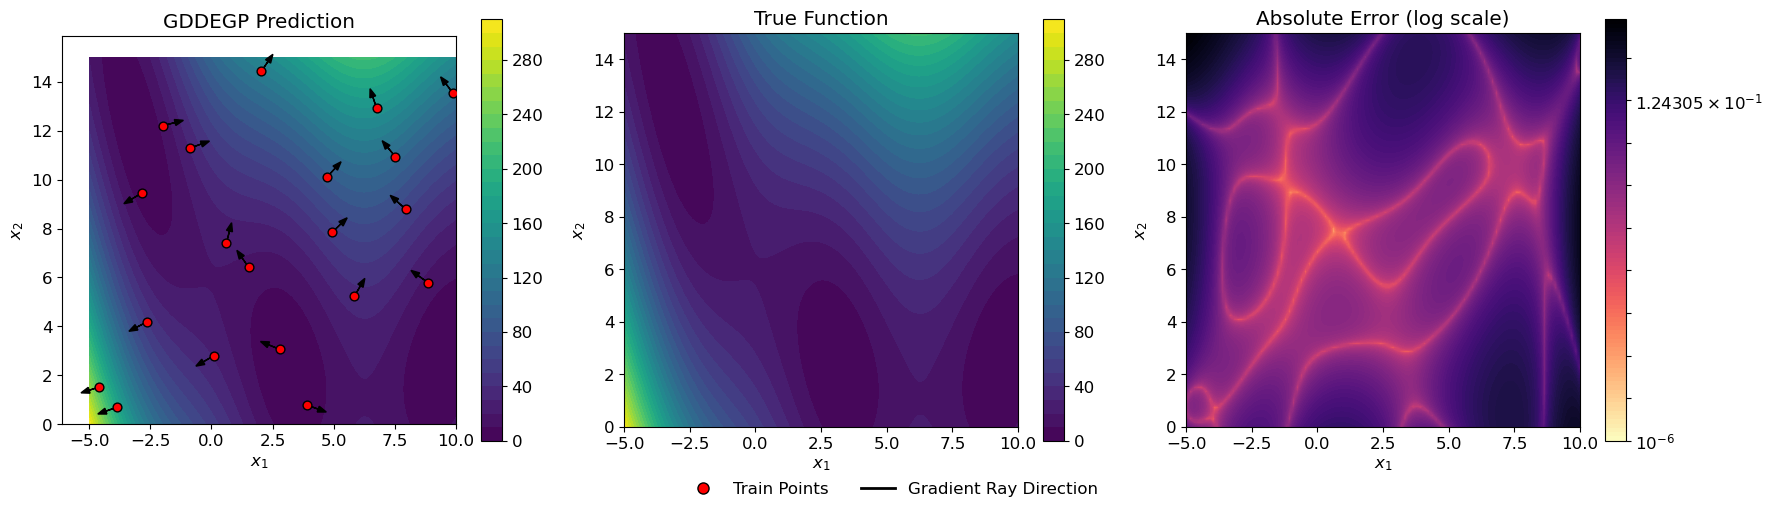

Final NRMSE: 0.000538


In [9]:
training_data = generate_training_data()
gp_model, params = train_model(training_data)
results = evaluate_model(gp_model, params, training_data)
visualize_results(results)
print(f"Final NRMSE: {results['nrmse']:.6f}")

In [10]:
import numpy as np
import pyoti.sparse as oti
import itertools
from full_gddegp.gddegp import gddegp
from scipy.stats import qmc
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
import utils

plt.rcParams.update({'font.size': 12})

In [11]:
n_order = 1
n_bases = 2
num_directions_per_point = 2
num_training_pts = 10
domain_bounds = ((-5.0, 10.0), (0.0, 15.0))
test_grid_resolution = 50
normalize_data = True
kernel = "SE"
kernel_type = "anisotropic"
n_restarts = 15
swarm_size = 250
random_seed = 1
np.random.seed(random_seed)

In [12]:
def true_function(X, alg=np):
    """Branin function compatible with both NumPy and pyoti arrays."""
    x, y = X[:, 0], X[:, 1]
    a, b, c, r, s, t = 1.0, 5.1/(4*np.pi**2), 5.0/np.pi, 6.0, 10.0, 1.0/(8*np.pi)
    return a*(y - b*x**2 + c*x - r)**2 + s*(1-t)*alg.cos(x) + s

def true_gradient(x, y):
    """Analytical gradient of the Branin function."""
    a, b, c, r, s, t = 1.0, 5.1/(4*np.pi**2), 5.0/np.pi, 6.0, 10.0, 1.0/(8*np.pi)
    gx = 2*a*(y - b*x**2 + c*x - r)*(-2*b*x + c) - s*(1-t)*np.sin(x)
    gy = 2*a*(y - b*x**2 + c*x - r)
    return gx, gy

In [13]:
def clipped_arrow(ax, origin, direction, length, bounds, color="black"):
    """Draw an arrow clipped to plot bounds."""
    x0, y0 = origin
    dx, dy = direction * length
    xlim, ylim = bounds
    tx = np.inf if dx == 0 else (xlim[1] - x0)/dx if dx > 0 else (xlim[0] - x0)/dx
    ty = np.inf if dy == 0 else (ylim[1] - y0)/dy if dy > 0 else (ylim[0] - y0)/dy
    t = min(1.0, tx, ty)
    ax.arrow(x0, y0, dx*t, dy*t, head_width=0.25, head_length=0.35, fc=color, ec=color)

In [14]:
def generate_training_data():
    """Generate GDDEGP training data with multiple directional derivatives per point."""
    # 1. Generate training points using Latin Hypercube Sampling
    sampler = qmc.LatinHypercube(d=n_bases, seed=random_seed)
    unit_samples = sampler.random(n=num_training_pts)
    X_train = qmc.scale(unit_samples,
                        [b[0] for b in domain_bounds],
                        [b[1] for b in domain_bounds])

    # 2. Create multiple rays per point: gradient + perpendicular
    rays_list = [[] for _ in range(num_directions_per_point)]
    for x, y in X_train:
        # Compute gradient and its angle
        gx, gy = true_gradient(x, y)
        theta_grad = np.arctan2(gy, gx)
        theta_perp = theta_grad + np.pi/2

        # Create unit vectors for both directions
        ray_grad = np.array([np.cos(theta_grad), np.sin(theta_grad)]).reshape(-1, 1)
        ray_perp = np.array([np.cos(theta_perp), np.sin(theta_perp)]).reshape(-1, 1)

        rays_list[0].append(ray_grad)
        rays_list[1].append(ray_perp)

    # 3. Apply global perturbations using hypercomplex tags
    X_pert = oti.array(X_train)
    for i in range(num_directions_per_point):
        e_tag = oti.e(i+1, order=n_order)
        for j in range(len(rays_list[i])):
            perturbation = oti.array(rays_list[i][j]) * e_tag
            X_pert[j, :] += perturbation.T

    # 4. Evaluate function with hypercomplex AD and truncate cross-derivatives
    f_hc = true_function(X_pert, alg=oti)
    for combo in itertools.combinations(range(1, num_directions_per_point+1), 2):
        f_hc = f_hc.truncate(combo)

    # 5. Extract function values and directional derivatives
    y_train_list = [f_hc.real.reshape(-1, 1)]
    der_indices_to_extract = [[[1, 1]], [[2, 1]]]
    for idx in der_indices_to_extract:
        y_train_list.append(f_hc.get_deriv(idx).reshape(-1, 1))

    return {'X_train': X_train,
            'y_train_list': y_train_list,
            'rays_list': rays_list,
            'der_indices': der_indices_to_extract}

In [15]:
def train_model(training_data):
    """Initialize and train GDDEGP model with multiple rays."""
    # Organize rays into arrays for each direction
    rays_array = [np.hstack(training_data['rays_list'][i])
                  for i in range(num_directions_per_point)]

    gp_model = gddegp(
        training_data['X_train'],
        training_data['y_train_list'],
        n_order=[1, 1],  # First-order derivatives for both directions
        rays_array=rays_array,
        der_indices=training_data['der_indices'],
        normalize=normalize_data,
        kernel=kernel,
        kernel_type=kernel_type
    )

    params =  gp_model.optimize_hyperparameters(
    optimizer='jade',
    pop_size = 100,
    n_generations = 15,
    local_opt_every = None,
    debug = False
    )
    return gp_model, params

In [16]:
def evaluate_model(gp_model, params, training_data):
    """Evaluate GDDEGP on a test grid."""
    # Create test grid
    gx = np.linspace(domain_bounds[0][0], domain_bounds[0][1], test_grid_resolution)
    gy = np.linspace(domain_bounds[1][0], domain_bounds[1][1], test_grid_resolution)
    X1_grid, X2_grid = np.meshgrid(gx, gy)
    X_test = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
    N_test = X_test.shape[0]

    # Dummy rays for prediction (not used for function values)
    dummy_ray = np.array([[1.0], [0.0]])
    rays_pred = [np.hstack([dummy_ray for _ in range(N_test)])
                 for _ in range(num_directions_per_point)]

    # Predict function values only
    y_pred_full = gp_model.predict(
        X_test, rays_pred, params,
        calc_cov=False, return_deriv=False
    )
    y_pred = y_pred_full[:N_test]

    # Compute error metrics
    y_true = true_function(X_test, alg=np)
    nrmse_val = utils.nrmse(y_true.flatten(), y_pred.flatten())

    return {'X_test': X_test, 'X1_grid': X1_grid, 'X2_grid': X2_grid,
            'y_pred': y_pred, 'y_true': y_true, 'nrmse': nrmse_val,
            'training_data': training_data}

In [17]:
def visualize_results(results):
    """Create 3-panel contour plot showing both ray directions."""
    training_data = results['training_data']
    X_train = training_data['X_train']
    rays_list = training_data['rays_list']
    X1, X2 = results['X1_grid'], results['X2_grid']

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # GDDEGP Prediction with multiple rays
    cf1 = axs[0].contourf(X1, X2, results['y_pred'].reshape(X1.shape),
                          levels=30, cmap='viridis')
    axs[0].scatter(X_train[:, 0], X_train[:, 1], c='red', s=40,
                   edgecolors='k', zorder=5)
    xlim, ylim = (domain_bounds[0], domain_bounds[1])

    # Draw arrows for all directions
    for i in range(num_directions_per_point):
        for pt, ray in zip(X_train, rays_list[i]):
            clipped_arrow(axs[0], pt, ray.flatten(), length=0.5,
                         bounds=(xlim, ylim), color='black')

    axs[0].set_title("GDDEGP Prediction (Multiple Rays)")
    fig.colorbar(cf1, ax=axs[0])

    # True function
    cf2 = axs[1].contourf(X1, X2, results['y_true'].reshape(X1.shape),
                          levels=30, cmap='viridis')
    axs[1].set_title("True Function")
    fig.colorbar(cf2, ax=axs[1])

    # Absolute Error (log scale)
    abs_error = np.abs(results['y_pred'].flatten() - results['y_true'].flatten()).reshape(X1.shape)
    abs_error_clipped = np.clip(abs_error, 1e-6, None)
    log_levels = np.logspace(np.log10(abs_error_clipped.min()),
                            np.log10(abs_error_clipped.max()), num=100)
    cf3 = axs[2].contourf(X1, X2, abs_error_clipped, levels=log_levels,
                          norm=LogNorm(), cmap='magma_r')
    fig.colorbar(cf3, ax=axs[2])
    axs[2].set_title("Absolute Error (log scale)")

    # Labels and formatting
    for ax in axs:
        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_2$")
        ax.set_aspect("equal")

    custom_lines = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
               markeredgecolor='k', markersize=8, label='Train Points'),
        Line2D([0], [0], color='black', lw=2, label='Ray Directions'),
    ]
    fig.legend(handles=custom_lines, loc='lower center', ncol=2,
               frameon=False, fontsize=12, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

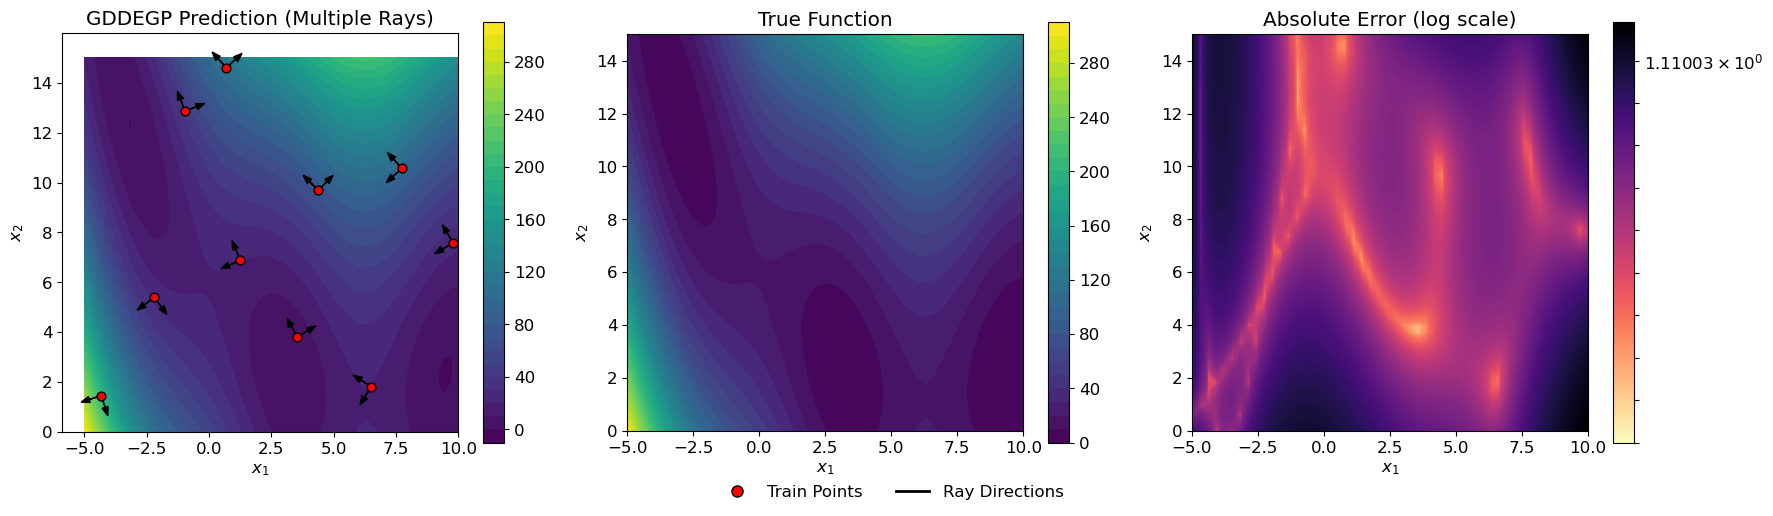

Final NRMSE: 0.001255


In [18]:
training_data = generate_training_data()
gp_model, params = train_model(training_data)
results = evaluate_model(gp_model, params, training_data)
visualize_results(results)
print(f"Final NRMSE: {results['nrmse']:.6f}")